In [101]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.datasets import make_friedman1 # for nonlinear relationships
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [102]:
X, y = make_friedman1(n_samples=1000, n_features=10, noise=0.1, random_state=5) # last 5 features do not affect output

In [103]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

In [104]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=5)

In [105]:
y_train.std()

np.float64(0.9969312137535918)

In [106]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

In [118]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(10, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x)
    

# with relu, gradients are basically linear, meaning cfd is nearly guaranteed to get the right sensitivity at extremely local windows
# changing to anything nonlinear gives better comparison of sensitivity approximation for nonlinear models

In [119]:
model = MLP()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

In [121]:
epochs = 500
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    preds = model(X_train_t)
    loss = loss_fn(preds, y_train_t)
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 50 == 0:
        print(f"epoch {epoch+1}, loss: {loss.item():.4f}")

epoch 50, loss: 0.0026
epoch 100, loss: 0.0022
epoch 150, loss: 0.0019
epoch 200, loss: 0.0016
epoch 250, loss: 0.0014
epoch 300, loss: 0.0013
epoch 350, loss: 0.0012
epoch 400, loss: 0.0011
epoch 450, loss: 0.0010
epoch 500, loss: 0.0009


In [122]:
model.eval()
with torch.no_grad():
    test_loss = loss_fn(model(X_test_t), y_test_t)
print(f"test loss: {test_loss.item():.4f}")

test loss: 0.0040


In [123]:
def get_autograd_sensitivities(instance: pd.Series, model, scaler_X):
    model.eval()
    
    # scale instance and convert to tensor, requires_grad=True for autograd
    instance_scaled = scaler_X.transform(instance.values.reshape(1, -1))
    instance_t = torch.tensor(instance_scaled, dtype=torch.float32, requires_grad=True)
    
    # forward pass
    output = model(instance_t)
    
    # backward pass
    output.backward()
    
    # gradients are d[out]/d[in] for each feature
    gradients = instance_t.grad.squeeze().detach().numpy()
    
    return dict(zip(instance.index, gradients))

In [124]:
import sys
sys.path.insert(0, "../sage")
from sage_base import Sage_Explainer

In [125]:
def predict_func(df: pd.DataFrame):
    model.eval()
    X_t = torch.tensor(df.values, dtype=torch.float32)  # no scaler, data already scaled
    with torch.no_grad():
        preds = model(X_t).squeeze(-1).numpy()
    return np.atleast_1d(preds)

In [126]:
feature_names = [f"x{i}" for i in range(10)]
X_train_df = pd.DataFrame(X_train, columns=feature_names)

In [127]:
explainer = Sage_Explainer(predict_func=predict_func)
explainer.fit(X_train_df, perturbation_strength=0.3)

In [132]:
def get_cfd_sensitivities(instance: pd.Series, model, scaler_X, epsilon=0.5):
    model.eval()
    
    instance_scaled = scaler_X.transform(instance.values.reshape(1, -1)).squeeze()
    
    sensitivities = {}
    for i, feature in enumerate(instance.index):
        # perturb forward and backward
        forward = instance_scaled.copy()
        backward = instance_scaled.copy()
        forward[i] += epsilon
        backward[i] -= epsilon
        
        forward_t = torch.tensor(forward, dtype=torch.float32).unsqueeze(0)
        backward_t = torch.tensor(backward, dtype=torch.float32).unsqueeze(0)
        
        with torch.no_grad():
            forward_pred = model(forward_t).item()
            backward_pred = model(backward_t).item()
        
        # (f(x+h) - f(x-h)) / 2h
        sensitivities[feature] = (forward_pred - backward_pred) / (2 * epsilon)
    
    return sensitivities

C:\Users\Yash\AppData\Local\Temp\ipykernel_21252\3302406841.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot([cfd_errors, sage_errors], labels=["CFD", "SAGE"], showfliers=False)


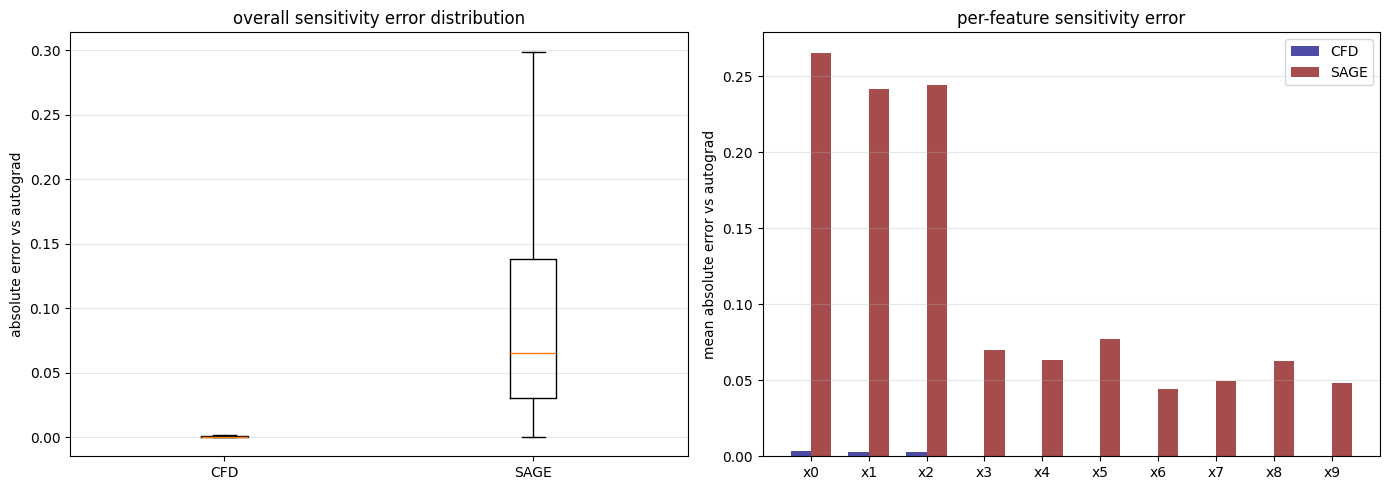

In [133]:
import matplotlib.pyplot as plt

# collect errors across 100 instances
np.random.seed(5)
sample_indices = np.random.choice(len(X_test), size=100, replace=False)
X_test_df = pd.DataFrame(X_test, columns=feature_names)

sage_errors = []
cfd_errors = []

sage_errors_per_feature = {f: [] for f in feature_names}
cfd_errors_per_feature = {f: [] for f in feature_names}

for idx in sample_indices:
    instance = X_test_df.iloc[idx]
    
    autograd_sens = get_autograd_sensitivities(instance, model, scaler_X)
    sage_sens = explainer.explain(instance)
    cfd_sens = get_cfd_sensitivities(instance, model, scaler_X)
    
    for feature in feature_names:
        true_val = autograd_sens[feature]
        sage_err = abs(sage_sens[feature] - true_val)
        cfd_err = abs(cfd_sens[feature] - true_val)
        
        sage_errors.append(sage_err)
        cfd_errors.append(cfd_err)
        sage_errors_per_feature[feature].append(sage_err)
        cfd_errors_per_feature[feature].append(cfd_err)

# plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# plot 1 - overall error distribution
ax1.boxplot([cfd_errors, sage_errors], labels=["CFD", "SAGE"], showfliers=False)
ax1.set_ylabel("absolute error vs autograd")
ax1.set_title("overall sensitivity error distribution")
ax1.grid(axis="y", alpha=0.3)

# plot 2 - per feature mean absolute error
x = np.arange(len(feature_names))
width = 0.35
cfd_means = [np.mean(cfd_errors_per_feature[f]) for f in feature_names]
sage_means = [np.mean(sage_errors_per_feature[f]) for f in feature_names]

ax2.bar(x - width/2, cfd_means, width, label="CFD", color="navy", alpha=0.7)
ax2.bar(x + width/2, sage_means, width, label="SAGE", color="maroon", alpha=0.7)
ax2.set_xticks(x)
ax2.set_xticklabels(feature_names)
ax2.set_ylabel("mean absolute error vs autograd")
ax2.set_title("per-feature sensitivity error")
ax2.legend()
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
"""
cfd with a small epsilon is numerically approximating the same instantaneous derivative that autograd computes analytically,
 so near-zero error between them is mathematically expected rather than a meaningful result. 
 sage is computing a fundamentally different quantity: the estimated rate of change over a realistic perturbation window scaled to the data distribution,
 making autograd an inappropriate ground truth for benchmarking it. A fair comparison would either use a non-differentiable model where autograd is unavailable, 
 or construct ground truth as the average slope across sage's own perturbation window.

"""